In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import csv
import os
import ternary
import matplotlib as mpl
import warnings

warnings.filterwarnings("ignore")


In [2]:
df = pd.read_csv('X.csv')
df.head()

,sw,sg,sw_inj,sg_inj,oil_bank,fg_inj
0,0.2,0.666667,0.15,0.85,False,0.999997
1,0.2,0.666667,0.20,0.80,False,0.999954
2,0.2,0.666667,0.25,0.75,False,0.076677
3,0.2,0.666667,0.30,0.70,False,0.021966
4,0.2,0.666667,0.35,0.65,False,0.006895


In [3]:
injs = df.iloc[:,2:4]
unique_injs = injs.drop_duplicates()
unique_injs

,sw_inj,sg_inj
0,0.15,0.85
1,0.20,0.80
2,0.25,0.75
3,0.30,0.70
4,0.35,0.65
5,0.40,0.60
6,0.45,0.55
7,0.50,0.50


In [4]:
inis = df.iloc[:,0:2]
unique_inis = inis.drop_duplicates()
unique_inis

,sw,sg
0,0.200000,0.666667
8,0.200000,0.633333
16,0.200000,0.600000
24,0.200000,0.566667
32,0.200000,0.533333
...,...,...
1640,0.766667,0.066667
1648,0.766667,0.033333
1656,0.800000,0.066667
1664,0.800000,0.033333


In [5]:
def check_inj(inj_idx):

    # Graph
    scale = 1
    mpl.rcParams['figure.figsize'] = (8, 7)
    figure, tax = ternary.figure(scale=scale)
    tax.gridlines(multiple=0.1, linewidth=0.5, color="blue")
    tax.boundary(linewidth=2.0)
    fontsize = 14
    tax.right_corner_label(r"$W$", fontsize=fontsize, color="black", fontweight="bold")
    tax.top_corner_label(r"$O$", fontsize=fontsize, color="black", fontweight="bold")
    tax.left_corner_label(r"$G$", fontsize=fontsize, color="black", fontweight="bold")

    # ALL POINTS
    # samples plot
    Sw = unique_inis.iloc[:,0]
    Sg = unique_inis.iloc[:,1]
    So = 1 - Sw - Sg
    points = [(sw, so, sg) for sw, so, sg in zip(Sw, So, Sg)]
    tax.scatter(points,
                marker='s',
                color='dimgray',
                alpha=1.0,
                label='no oil bank formation')

    Sw = unique_injs.iloc[:,0]
    Sg = unique_injs.iloc[:,1]
    So = 1 - Sw - Sg
    points = [(sw, so, sg) for sw, so, sg in zip(Sw, So, Sg)]
    tax.scatter(points,
                marker='s',
                color='dimgray',
                alpha=1.0)

    filtered_injs = df.query(
            f'sw_inj == {unique_injs.iloc[inj_idx,0]} and sg_inj == {unique_injs.iloc[inj_idx,1]}'
        )
    OB = filtered_injs[filtered_injs['oil_bank'] == True].index

    if len(OB) > 0:
        # Initial conditions
        Sw, Sg = df.iloc[OB.values,0], df.iloc[OB.values,1]
        So = 1 - Sw - Sg
        points = [(sw, so, sg) for sw, so, sg in zip(Sw, So, Sg)]
        tax.scatter(points, marker='s', color='red', label="Samples")

    # Injection conditions
    Sw, Sg = unique_injs.iloc[inj_idx,0], unique_injs.iloc[inj_idx,1]
    So = 1 - Sw - Sg
    points = [(Sw, So, Sg)]
    tax.scatter(points, marker='s', color='red', s=80)


    tax.ticks(axis='lbr', linewidth=1, offset=0.025, multiple=0.1, tick_formats="%.1f")
    tax.get_axes().axis('off')
    tax.clear_matplotlib_ticks()

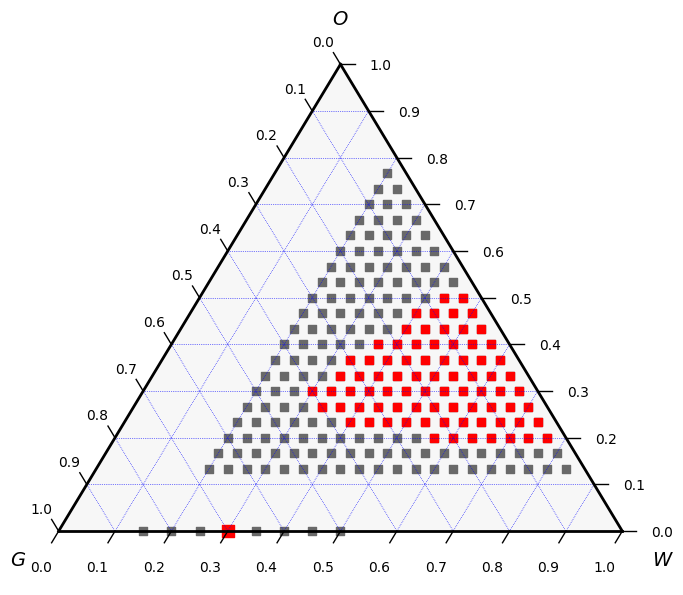

In [6]:
inj_idx = 3
check_inj(inj_idx)

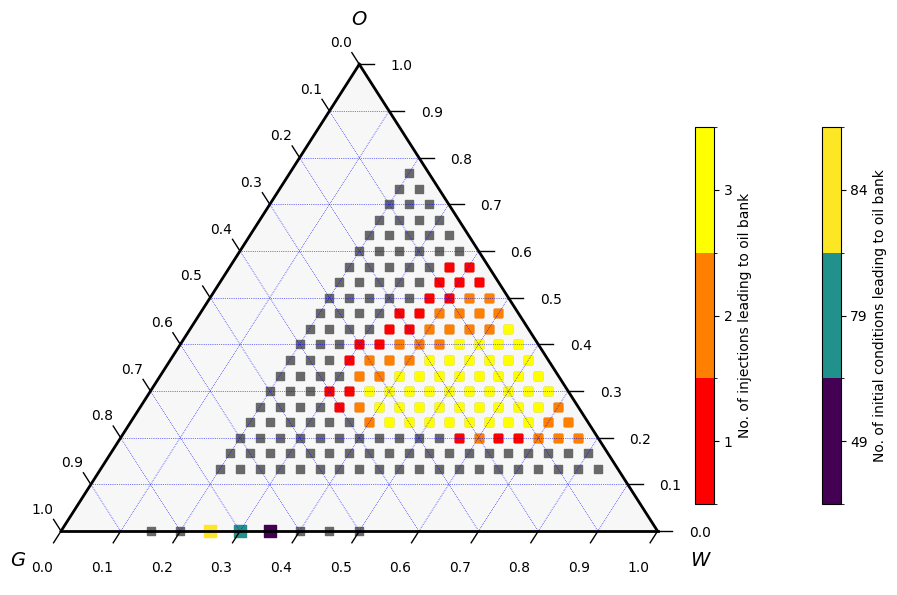

In [7]:
# Graph
scale = 1
mpl.rcParams['figure.figsize'] = (12, 7)
figure, tax = ternary.figure(scale=scale)
tax.gridlines(multiple=0.1, linewidth=0.5, color="blue")
tax.boundary(linewidth=2.0)
fontsize = 14
tax.right_corner_label(r"$W$", fontsize=fontsize, color="black", fontweight="bold")
tax.top_corner_label(r"$O$", fontsize=fontsize, color="black", fontweight="bold")
tax.left_corner_label(r"$G$", fontsize=fontsize, color="black", fontweight="bold")

# samples plot
Sw = unique_inis.iloc[:,0]
Sg = unique_inis.iloc[:,1]
So = 1 - Sw - Sg
points = [(sw, so, sg) for sw, so, sg in zip(Sw, So, Sg)]
tax.scatter(points,
            marker='s',
            color='dimgray',
            alpha=1.0,
            label='no oil bank formation')

Sw = unique_injs.iloc[:,0]
Sg = unique_injs.iloc[:,1]
So = 1 - Sw - Sg
points = [(sw, so, sg) for sw, so, sg in zip(Sw, So, Sg)]
tax.scatter(points,
            marker='s',
            color='dimgray',
            alpha=1.0)

# Filterind

ob_counts = []
for i in range(unique_injs.shape[0]):
    filtered_injs = df.query(
        f'sw_inj == {unique_injs.iloc[i,0]} and sg_inj == {unique_injs.iloc[i,1]}'
    )
    OB = filtered_injs[filtered_injs['oil_bank'] == True].index
    ob_counts.append(len(OB))

ob_counts = np.array(ob_counts)
valid_mask = ob_counts > 0
valid_counts = ob_counts[valid_mask]

# continuous colors
# cmap = plt.cm.viridis
# norm = mpl.colors.Normalize(vmin=valid_counts.min(), vmax=valid_counts.max())

# discrete colors
valid_counts = np.unique(valid_counts)
bounds = np.append(valid_counts, valid_counts[-1] + 1)
cmap = plt.cm.get_cmap("viridis", len(valid_counts))
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)



ob_counts_ini = []
for i in range(unique_inis.shape[0]):
    filtered_inis = df.query(
        f'sw == {unique_inis.iloc[i,0]} and sg == {unique_inis.iloc[i,1]}'
    )
    OB = filtered_inis[filtered_inis['oil_bank'] == True].index
    ob_counts_ini.append(len(OB))

ob_counts_ini = np.array(ob_counts_ini)
valid_mask_ini = ob_counts_ini > 0
valid_counts_ini = ob_counts_ini[valid_mask_ini]

valid_counts_ini = np.unique(valid_counts_ini)
bounds_ini = np.append(valid_counts_ini, valid_counts_ini[-1] + 1)
cmap_ini = plt.cm.get_cmap("autumn", len(valid_counts_ini))
norm_ini = mpl.colors.BoundaryNorm(bounds_ini, cmap_ini.N)


for i in range(unique_injs.shape[0]):

    if ob_counts[i] == 0:
        continue

    filtered_injs = df.query(
        f'sw_inj == {unique_injs.iloc[i,0]} and sg_inj == {unique_injs.iloc[i,1]}'
    )
    OB = filtered_injs[filtered_injs['oil_bank'] == True].index

    # Injection condition
    Sw_inj, Sg_inj = unique_injs.iloc[i,0], unique_injs.iloc[i,1]
    So_inj = 1 - Sw_inj - Sg_inj

    color = cmap(norm(len(OB)))

    tax.scatter([(Sw_inj, So_inj, Sg_inj)],
                marker='s',
                color=color,
                s=80)
    

    for i in range(unique_inis.shape[0]):
            
        if ob_counts_ini[i] == 0:
            continue

        filtered_inis = df.query(
            f'sw == {unique_inis.iloc[i,0]} and sg == {unique_inis.iloc[i,1]}'
        )
        OB = filtered_inis[filtered_inis['oil_bank'] == True].index

        # Initial condition
        Sw, Sg = unique_inis.iloc[i,0], unique_inis.iloc[i,1]
        So = 1 - Sw - Sg

        color_ini = cmap_ini(norm_ini(len(OB)))

        tax.scatter([(Sw, So, Sg)],
                    marker='s',
                    color=color_ini)



tax.ticks(axis='lbr', linewidth=1, offset=0.025, multiple=0.1, tick_formats="%.1f")
tax.get_axes().axis('off')
tax.clear_matplotlib_ticks()

# continuous colors
# sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([])
# ax = tax.get_axes()
# cbar = figure.colorbar(sm, ax=ax, pad=0.02)
# cbar.set_label("Number of Oil Bank Samples per Injection")

# discrete colors
tick_positions = (bounds[:-1] + bounds[1:]) / 2

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

ax = tax.get_axes()
cbar = figure.colorbar(sm, ax=ax, pad=0.01, shrink=0.7)

tick_positions = (bounds[:-1] + bounds[1:]) / 2

cbar.set_ticks(tick_positions)
cbar.set_ticklabels(valid_counts)
cbar.set_label("No. of initial conditions leading to oil bank")

sm_ini = mpl.cm.ScalarMappable(cmap=cmap_ini, norm=norm_ini)
sm_ini.set_array([])

cbar_ini = figure.colorbar(sm_ini, ax=ax, pad=0.01, shrink=0.7)

tick_positions_ini = (bounds_ini[:-1] + bounds_ini[1:]) / 2

cbar_ini.set_ticks(tick_positions_ini)
cbar_ini.set_ticklabels(valid_counts_ini)
cbar_ini.set_label("No. of injections leading to oil bank")

# plt.legend()
plt.show()

In [8]:
df.head()

,sw,sg,sw_inj,sg_inj,oil_bank,fg_inj
0,0.2,0.666667,0.15,0.85,False,0.999997
1,0.2,0.666667,0.20,0.80,False,0.999954
2,0.2,0.666667,0.25,0.75,False,0.076677
3,0.2,0.666667,0.30,0.70,False,0.021966
4,0.2,0.666667,0.35,0.65,False,0.006895
